# 03 — Visualizations (Deliverable C: fig01–fig09)

Inputs: raw files in `data/raw/` (read only) and cleaned files in `data/processed/`. Zone types come from `02_analysis_report.ipynb`; fig10–fig12 are produced with the models in `04_modeling_and_evaluation.ipynb`. Captions: `figures/figure_captions.md`.

### Setup

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

pd.set_option("display.width", 160)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
TRAIN_START, TRAIN_END = "2025-01-01 00:00", "2025-10-31 23:00"

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_2, INK_3, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1", "#fcfcfb"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def save(fig, name):
    """Save a figure to figures/ and show it."""
    fig.savefig(FIG_DIR / name)
    plt.show()

### Load data

In [2]:
raw_trips = pd.read_csv(RAW_DIR / "ride_demand_train.csv")
raw_weather = pd.read_csv(RAW_DIR / "weather_hourly.csv")
raw_events = pd.read_csv(RAW_DIR / "events_calendar.csv", dtype=str)

trips = pd.read_csv(PROC_DIR / "trips_clean.csv", parse_dates=["pickup_hour"])
weather = pd.read_csv(PROC_DIR / "weather_clean.csv", parse_dates=["timestamp"])
events = pd.read_csv(PROC_DIR / "events_clean.csv", parse_dates=["start_datetime", "end_datetime"])
events = events[events["is_cancelled"] == 0]
zone_type = pd.read_csv(PROC_DIR / "zone_types.csv", index_col="zone")["zone_type"]
SHORT_ORDER = ["Business / office", "Mixed hub", "Market", "Residential", "Leisure / nightlife"]
TYPE_ORDER = sorted(zone_type.unique(), key=lambda t: SHORT_ORDER.index(t.split(" (")[0]))

trips["date"] = trips["pickup_hour"].dt.normalize()
trips["hour"] = trips["pickup_hour"].dt.hour
trips["dow"] = trips["pickup_hour"].dt.dayofweek
trips["day_type"] = np.where(trips["dow"] >= 5, "weekend", "weekday")
trips["zone_type"] = trips["zone"].map(zone_type)
holiday_rows = events[events["event_type"] == "public_holiday"]
holiday_dates = set(holiday_rows["start_datetime"].dt.normalize())
trips["is_holiday"] = trips["date"].isin(holiday_dates)
print(trips.shape, weather.shape, events["event_id"].nunique(), "active events")

(82742, 15) (7656, 8) 153 active events


## fig01 — Gaps and missingness

In [3]:
t_trips = pd.to_numeric(raw_trips["trips"])
ratio = t_trips / raw_trips["active_drivers"]
att = raw_events["expected_attendance"]
end = raw_events["end_datetime"]

issues = pd.DataFrame([
    ("Trips", "trips", "missing", t_trips.isna().sum()),
    ("Trips", "trips", "invalid", (t_trips == -1).sum() + (ratio > 3).sum()),
    ("Trips", "avg_fare_birr", "missing", raw_trips["avg_fare_birr"].isna().sum()),
    ("Trips", "avg_wait_min", "invalid", (raw_trips["avg_wait_min"] == -1).sum()),
    ("Weather", "temp_c", "missing", raw_weather["temp_c"].isna().sum()),
    ("Weather", "temp_c", "invalid", (raw_weather["temp_c"] > 40).sum()),
    ("Weather", "humidity_pct", "missing", raw_weather["humidity_pct"].isna().sum()),
    ("Weather", "rain_mm", "invalid", (raw_weather["rain_mm"] == -9999).sum()),
    ("Weather", "hours absent", "missing", int(weather["weather_row_missing"].sum())),
    ("Events", "end_datetime", "missing", end.isna().sum()),
    ("Events", "expected_attendance", "missing", att.isna().sum()),
    ("Events", "expected_attendance", "invalid", (att.notna() & ~att.str.strip().str.fullmatch(r"\d+", na=False)).sum()),
    ("Events", "venue", "missing", raw_events["venue"].isna().sum()),
], columns=["table", "column", "kind", "rows"])
n_rows = {"Trips": len(raw_trips), "Weather": len(raw_weather), "Events": len(raw_events)}
issues["pct"] = 100 * issues["rows"] / issues["table"].map(n_rows)
issues

,table,column,kind,rows,pct
0,Trips,trips,missing,845,0.988767
1,Trips,trips,invalid,806,0.943131
2,Trips,avg_fare_birr,missing,1277,1.494266
3,Trips,avg_wait_min,invalid,1707,1.997426
4,Weather,temp_c,missing,42,0.557177
5,Weather,temp_c,invalid,353,4.682940
6,Weather,humidity_pct,missing,153,2.029716
7,Weather,rain_mm,invalid,76,1.008225
8,Weather,hours absent,missing,193,2.560361
9,Events,end_datetime,missing,4,2.424242


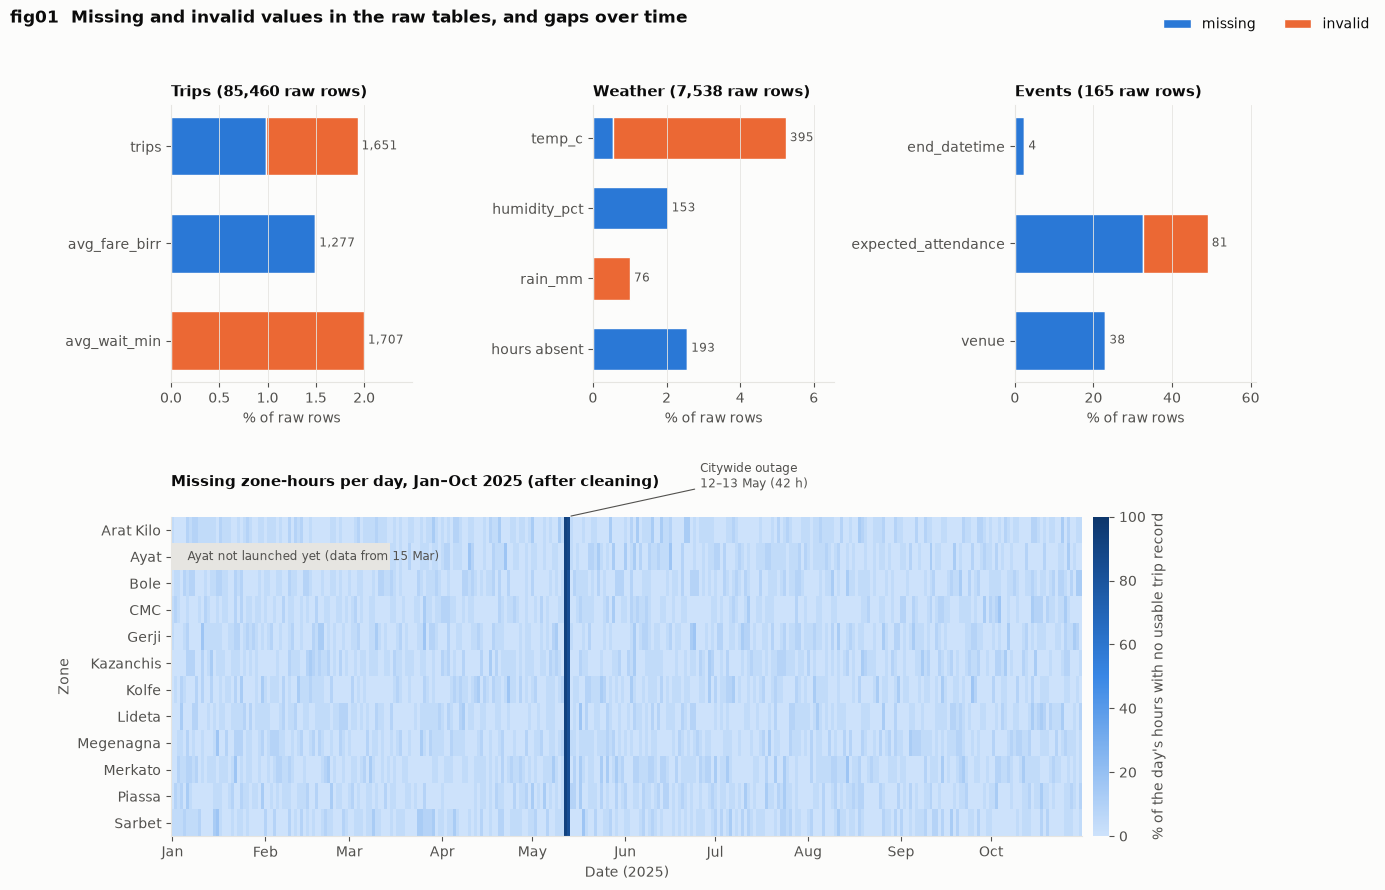

In [4]:
hours = pd.date_range(TRAIN_START, TRAIN_END, freq="h")
grid = pd.MultiIndex.from_product([sorted(trips["zone"].unique()), hours], names=["zone", "pickup_hour"]).to_frame(index=False)
grid = grid.merge(trips[["zone", "pickup_hour"]].assign(present=1), how="left").fillna({"present": 0})
first_seen = trips.groupby("zone")["pickup_hour"].min()
grid["before_launch"] = grid["pickup_hour"] < grid["zone"].map(first_seen)
grid["date"] = grid["pickup_hour"].dt.normalize()
daily = grid.groupby(["zone", "date"]).agg(missing=("present", lambda s: 100 * (1 - s.mean())), before=("before_launch", "all"))
mat = daily["missing"].where(~daily["before"]).unstack()

fig = plt.figure(figsize=(14, 9.5))
gs = GridSpec(2, 3, height_ratios=[1, 1.15], hspace=0.45, wspace=0.75, figure=fig)
colors = {"missing": BLUE, "invalid": ORANGE}
for k, table in enumerate(["Trips", "Weather", "Events"]):
    ax = fig.add_subplot(gs[0, k])
    sub = issues[issues["table"] == table]
    labels = list(dict.fromkeys(sub["column"]))
    left = np.zeros(len(labels))
    for kind in ["missing", "invalid"]:
        vals = np.array([sub.loc[(sub["column"] == c) & (sub["kind"] == kind), "pct"].sum() for c in labels])
        ax.barh(labels, vals, left=left, color=colors[kind], height=0.6, label=kind, edgecolor=SURFACE, linewidth=1)
        left += vals
    for y, (c, total) in enumerate(zip(labels, left)):
        n = int(sub.loc[sub["column"] == c, "rows"].sum())
        ax.text(total, y, f" {n:,}", va="center", fontsize=8.5, color=INK_2)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.25)
    ax.set_xlabel("% of raw rows")
    ax.set_title(f"{table} ({n_rows[table]:,} raw rows)")
fig.legend(*fig.axes[0].get_legend_handles_labels(), frameon=False, loc="upper right", ncol=2, bbox_to_anchor=(0.99, 0.985))

ax = fig.add_subplot(gs[1, :])
cmap = SEQ_BLUE.copy()
cmap.set_bad(GRID)
im = ax.imshow(np.ma.masked_invalid(mat.values), aspect="auto", cmap=cmap, vmin=0, vmax=100, interpolation="nearest")
ax.set_yticks(range(len(mat)), mat.index)
ticks = [i for i, d in enumerate(mat.columns) if d.day == 1]
ax.set_xticks(ticks, [mat.columns[i].strftime("%b") for i in ticks])
ax.set_xlabel("Date (2025)")
ax.set_ylabel("Zone")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label("% of the day's hours with no usable trip record", color=INK_2)
cb.outline.set_visible(False)
outage = mat.columns.get_loc(pd.Timestamp("2025-05-12"))
ax.annotate("Citywide outage\n12–13 May (42 h)", xy=(outage + 1, -0.5), xytext=(outage + 45, -1.6),
            fontsize=8.5, color=INK_2, annotation_clip=False, arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.8))
ax.text(5, list(mat.index).index("Ayat"), "Ayat not launched yet (data from 15 Mar)", va="center", fontsize=8.5, color=INK_2)
ax.set_title("Missing zone-hours per day, Jan–Oct 2025 (after cleaning)", pad=22)
fig.suptitle("fig01  Missing and invalid values in the raw tables, and gaps over time", x=0.01, ha="left", fontweight="bold")
save(fig, "fig01_gaps_and_missingness.png")

## fig02 — Before and after cleaning

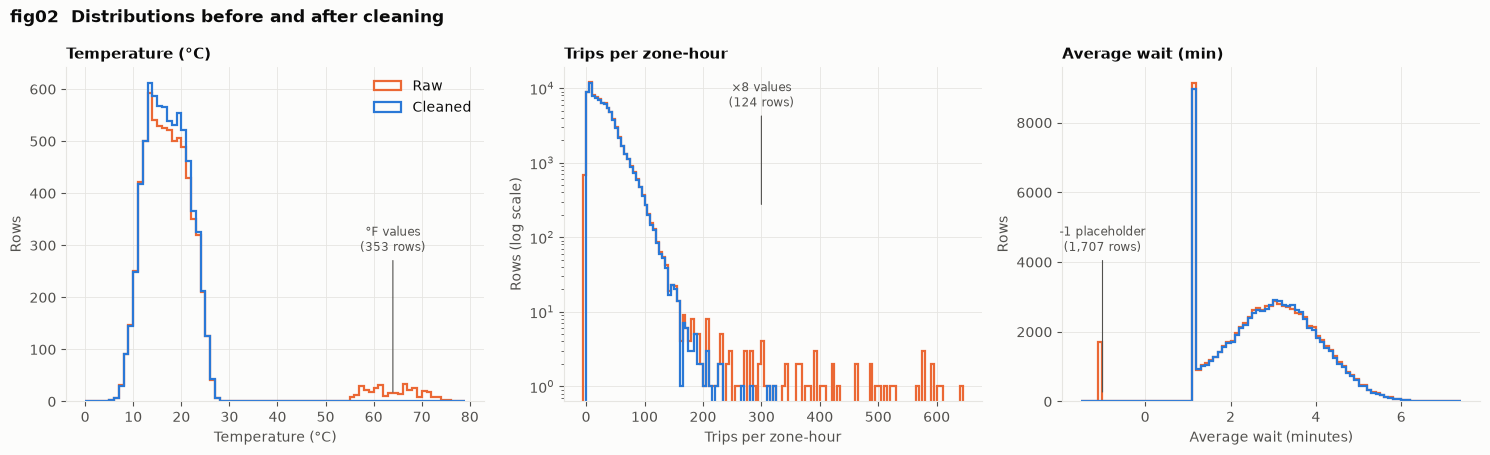

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
XLABELS = ["Temperature (°C)", "Trips per zone-hour", "Average wait (minutes)"]
panels = [
    ("Temperature (°C)", raw_weather["temp_c"], weather.loc[weather["weather_row_missing"] == 0, "temp_c"],
     np.arange(0, 80, 1), "°F values\n(353 rows)", 64),
    ("Trips per zone-hour", t_trips, trips["trips"], np.arange(-5, 650, 5), "×8 values\n(124 rows)", 300),
    ("Average wait (min)", raw_trips["avg_wait_min"], trips["avg_wait_min"], np.arange(-1.5, 7.5, 0.1), "-1 placeholder\n(1,707 rows)", -1),
]
for ax, (title, before, after, bins, note, x_note) in zip(axes, panels):
    ax.hist(before.dropna(), bins=bins, histtype="step", color=ORANGE, linewidth=1.6, label="Raw")
    ax.hist(after.dropna(), bins=bins, histtype="step", color=BLUE, linewidth=1.6, label="Cleaned")
    ax.set_title(title)
    ax.set_xlabel(XLABELS[list(axes).index(ax)])
    ax.set_ylabel("Rows")
    ax.annotate(note, xy=(x_note, ax.get_ylim()[1] * 0.02), xytext=(x_note, ax.get_ylim()[1] * 0.45),
                ha="center", fontsize=8.5, color=INK_2, arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.8))
axes[1].set_yscale("log")
axes[1].set_ylabel("Rows (log scale)")
axes[0].legend(frameon=False)
fig.suptitle("fig02  Distributions before and after cleaning", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig02_before_after_cleaning.png")

## fig03 — Demand trend with holidays

Daily mean trips per zone-hour for the 11 zones with data all year (Ayat joins on 15 Mar), so the trend is not distorted by Ayat's launch or by missing hours; days with < 80% coverage (the 12–13 May outage) are left blank.

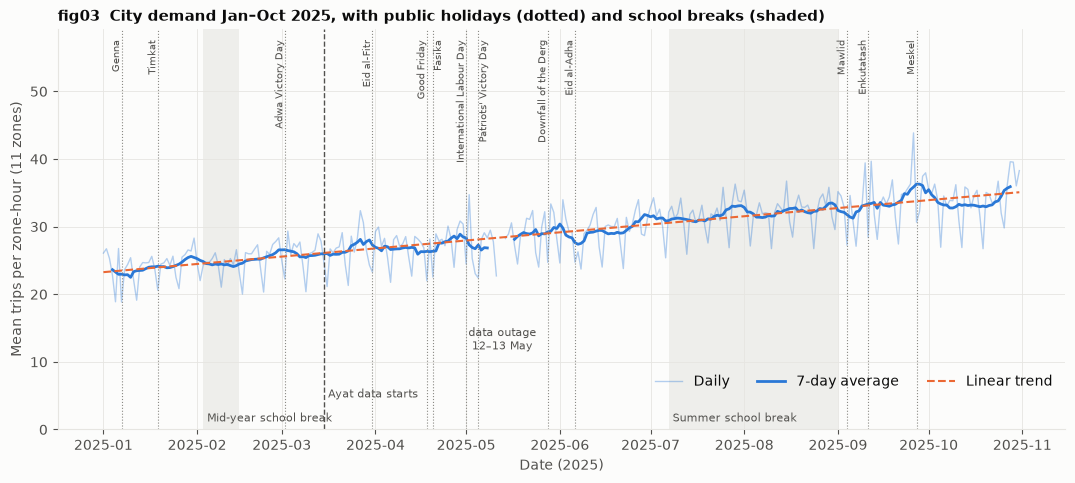

In [6]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
steady = trips[trips["zone"] != "Ayat"]
daily = steady.groupby("date")["trips"].agg(["mean", "size"])
daily = daily["mean"].where(daily["size"] >= 0.8 * 24 * steady["zone"].nunique())
hol = holiday_rows.drop_duplicates("event_id").sort_values("start_datetime")
breaks = events[events["event_type"] == "school_break"].drop_duplicates("event_id")
fig, ax = plt.subplots(figsize=(13, 5.2))
for b in breaks.itertuples():
    ax.axvspan(b.start_datetime, b.end_datetime, color=GRID, alpha=0.6, linewidth=0)
    ax.text(b.start_datetime, 0.02, " " + b.event_name, transform=ax.get_xaxis_transform(), fontsize=8, color=INK_2)
ax.plot(daily.index, daily.values, color=BLUE, alpha=0.35, linewidth=1, label="Daily")
ax.plot(daily.index, daily.rolling(7, center=True).mean(), color=BLUE, label="7-day average")
xs = np.arange(len(daily))
ok = daily.notna().values
ax.plot(daily.index, np.polyval(np.polyfit(xs[ok], daily.values[ok], 1), xs), color=ORANGE, linestyle="--", linewidth=1.5, label="Linear trend")
prev = None
for h in hol.itertuples():
    ax.axvline(h.start_datetime, color=INK_3, linewidth=0.8, linestyle=":")
    close = prev is not None and (h.start_datetime - prev).days < 6
    ax.text(h.start_datetime, 0.98, h.event_name.split(" (")[0] + " ", transform=ax.get_xaxis_transform(), rotation=90,
            va="top", ha="left" if close else "right", fontsize=7.5, color=INK_2)
    prev = h.start_datetime
gap = daily[daily.isna()].index
if len(gap):
    ax.text(gap[0] + pd.Timedelta(days=1), 0.2, "data outage\n12–13 May", transform=ax.get_xaxis_transform(), ha="center", fontsize=8, color=INK_2)
ayat_start = trips.loc[trips["zone"] == "Ayat", "pickup_hour"].min()
ax.axvline(ayat_start, color=INK_2, linewidth=1, linestyle="--")
ax.text(ayat_start, 0.08, " Ayat data starts", transform=ax.get_xaxis_transform(), fontsize=8, color=INK_2)
ax.set_ylim(0, daily.max() * 1.35)
ax.set_xlabel("Date (2025)")
ax.set_ylabel("Mean trips per zone-hour (11 zones)")
ax.legend(loc="lower right", bbox_to_anchor=(1, 0.07), frameon=False, ncol=3)
ax.set_title("fig03  City demand Jan–Oct 2025, with public holidays (dotted) and school breaks (shaded)")
save(fig, "fig03_demand_trend_with_holidays.png")

## fig04 — Hour × weekday heatmap

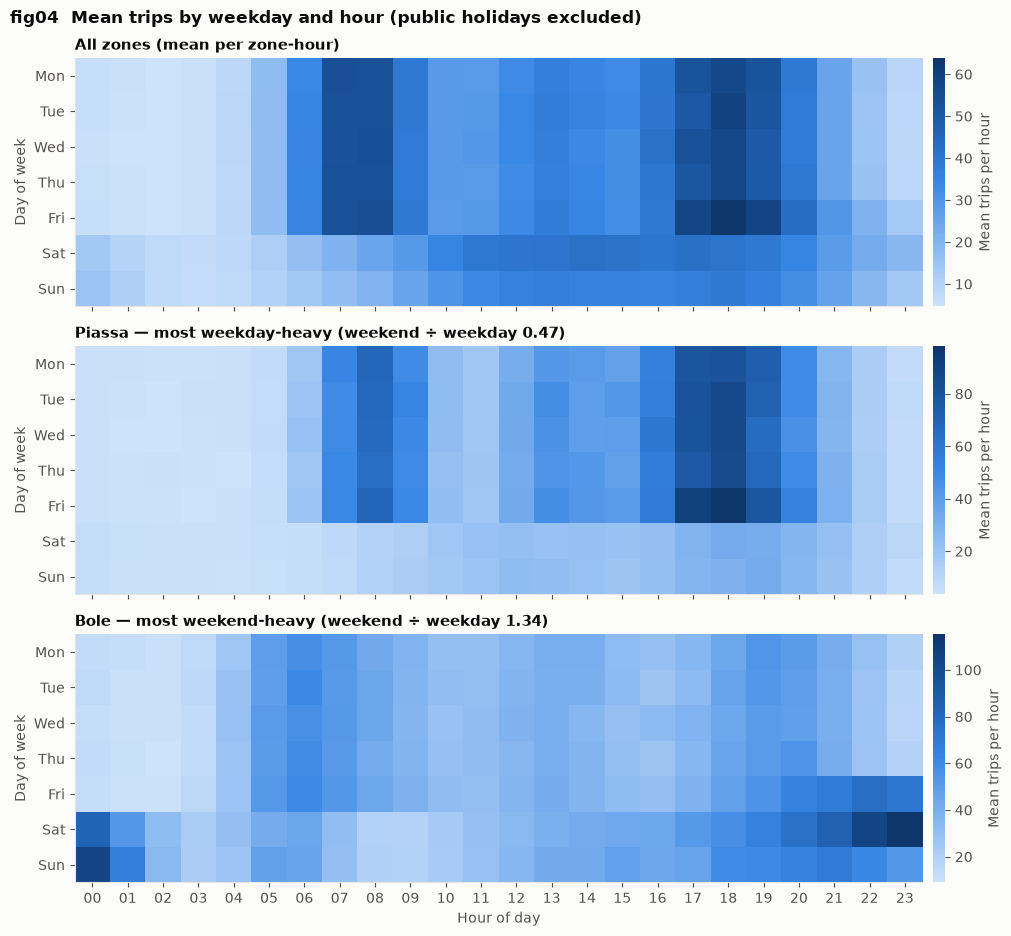

In [7]:
non_holiday = trips[~trips["is_holiday"]]
wkr = non_holiday.groupby(["zone", non_holiday["dow"] >= 5])["trips"].mean().unstack()
wkr = (wkr[True] / wkr[False]).sort_values()
low_zone, high_zone = wkr.index[0], wkr.index[-1]
panels = [("All zones (mean per zone-hour)", non_holiday),
          (f"{low_zone} — most weekday-heavy (weekend ÷ weekday {wkr[low_zone]:.2f})", non_holiday[non_holiday["zone"] == low_zone]),
          (f"{high_zone} — most weekend-heavy (weekend ÷ weekday {wkr[high_zone]:.2f})", non_holiday[non_holiday["zone"] == high_zone])]
fig, axes = plt.subplots(3, 1, figsize=(11, 9.5), sharex=True)
for ax, (title, data) in zip(axes, panels):
    grid_ = data.groupby(["dow", "hour"])["trips"].mean().unstack()
    im = ax.imshow(grid_, aspect="auto", cmap=SEQ_BLUE)
    ax.set_yticks(range(7), DOW)
    ax.set_ylabel("Day of week")
    ax.set_title(title)
    ax.grid(False)
    cb = fig.colorbar(im, ax=ax, pad=0.01)
    cb.set_label("Mean trips per hour", color=INK_2)
    cb.outline.set_visible(False)
axes[-1].set_xticks(range(24), [f"{h:02d}" for h in range(24)])
axes[-1].set_xlabel("Hour of day")
fig.suptitle("fig04  Mean trips by weekday and hour (public holidays excluded)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig04_hour_by_weekday_heatmap.png")

## fig05 — Weekday vs weekend profile by zone type

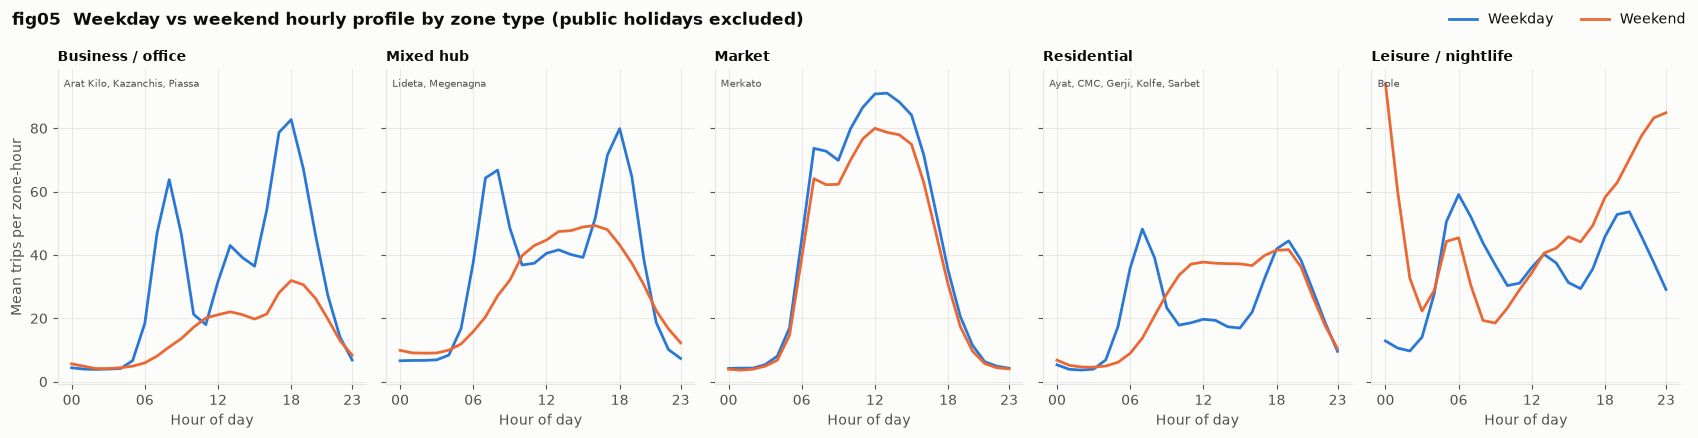

In [8]:
by_type = non_holiday.assign(weekend=non_holiday["dow"] >= 5).groupby(["zone_type", "weekend", "hour"])["trips"].mean()
fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(17, 4.4), sharey=True)
for ax, t in zip(axes, TYPE_ORDER):
    ax.plot(range(24), by_type.loc[(t, False)], color=BLUE, label="Weekday")
    ax.plot(range(24), by_type.loc[(t, True)], color=ORANGE, label="Weekend")
    ax.set_title(t.split(" (")[0], fontsize=10)
    ax.text(0.02, 0.97, ", ".join(sorted(zone_type.index[zone_type == t])), transform=ax.transAxes, va="top", fontsize=7.5, color=INK_2)
    ax.set_xticks([0, 6, 12, 18, 23], ["00", "06", "12", "18", "23"])
    ax.set_xlabel("Hour of day")
axes[0].set_ylabel("Mean trips per zone-hour")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, frameon=False)
fig.suptitle("fig05  Weekday vs weekend hourly profile by zone type (public holidays excluded)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig05_zone_profiles.png")

## fig06 — Weather time-zone check

Both weather timestamp formats are UTC. Left: the daily temperature curve on the raw UTC clock peaks at midday; converted to Addis time (+3h) it peaks mid-afternoon. Right: slash-format rows fit smoothly between their neighbouring `Z` rows only at a 0-hour shift, so they are on the same UTC clock.

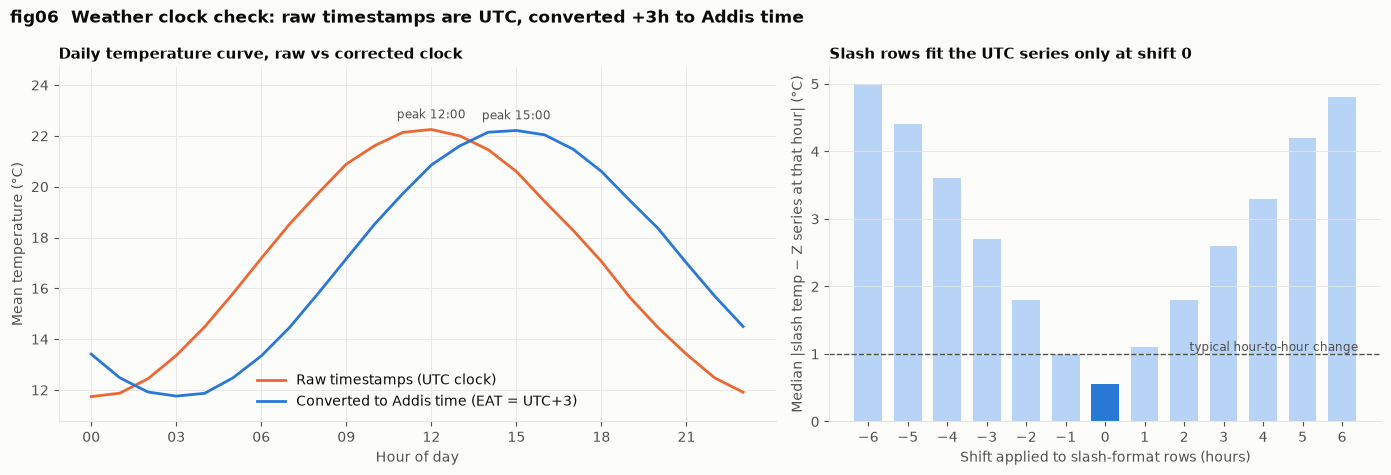

fit by shift: {-6: np.float64(5.0), -5: np.float64(4.4), -4: np.float64(3.6), -3: np.float64(2.7), -2: np.float64(1.8), -1: np.float64(1.0), 0: np.float64(0.55), 1: np.float64(1.1), 2: np.float64(1.8), 3: np.float64(2.6), 4: np.float64(3.3), 5: np.float64(4.2), 6: np.float64(4.8)} | self: 1.0


In [9]:
temp = np.where(raw_weather["temp_c"] > 40, (raw_weather["temp_c"] - 32) * 5 / 9, raw_weather["temp_c"])
is_z = raw_weather["timestamp"].str.endswith("Z")
t_raw = pd.Series(pd.NaT, index=raw_weather.index, dtype="datetime64[ns]")
t_raw[is_z] = pd.to_datetime(raw_weather.loc[is_z, "timestamp"], format="%Y-%m-%dT%H:%M:%SZ")
t_raw[~is_z] = pd.to_datetime(raw_weather.loc[~is_z, "timestamp"], format="%d/%m/%Y %H:%M")
obs = pd.DataFrame({"t": t_raw, "temp": temp}).dropna()
curve_utc = obs.groupby(obs["t"].dt.hour)["temp"].mean()
curve_eat = weather[weather["weather_imputed"] == 0].groupby(weather["timestamp"].dt.hour)["temp_c"].mean()

z_series = obs[is_z.loc[obs.index]].groupby("t")["temp"].mean().asfreq("h").interpolate(limit_area="inside")
slash = obs[~is_z.loc[obs.index]]
shifts = range(-6, 7)
fit = [np.nanmedian(np.abs(slash["temp"].values - z_series.reindex(slash["t"] + pd.Timedelta(hours=k)).values))
       for k in shifts]
self_fit = z_series.diff().abs().median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
ax.plot(curve_utc.index, curve_utc.values, color=ORANGE, label="Raw timestamps (UTC clock)")
ax.plot(curve_eat.index, curve_eat.values, color=BLUE, label="Converted to Addis time (EAT = UTC+3)")
for curve, color in [(curve_utc, ORANGE), (curve_eat, BLUE)]:
    ax.annotate(f"peak {curve.idxmax():02d}:00", xy=(curve.idxmax(), curve.max()), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK_2)
ax.set_xticks(range(0, 24, 3), [f"{h:02d}" for h in range(0, 24, 3)])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean temperature (°C)")
ax.set_ylim(curve_eat.min() - 1, curve_eat.max() + 2.5)
ax.legend(frameon=False, loc="lower center")
ax.set_title("Daily temperature curve, raw vs corrected clock")

ax = axes[1]
ax.bar(list(shifts), fit, color=[BLUE if k == 0 else "#b7d3f6" for k in shifts], width=0.7)
ax.axhline(self_fit, color=INK_2, linestyle="--", linewidth=1)
ax.text(6.4, self_fit, " typical hour-to-hour change", va="bottom", ha="right", fontsize=8.5, color=INK_2)
ax.set_xticks(list(shifts))
ax.set_xlabel("Shift applied to slash-format rows (hours)")
ax.set_ylabel("Median |slash temp − Z series at that hour| (°C)")
ax.grid(axis="x", visible=False)
ax.set_title("Slash rows fit the UTC series only at shift 0")
fig.suptitle("fig06  Weather clock check: raw timestamps are UTC, converted +3h to Addis time",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig06_weather_timezone_check.png")
print("fit by shift:", dict(zip(shifts, np.round(fit, 2))), "| self:", round(self_fit, 2))

## fig07 — Rain effect

Demand ratio = actual trips ÷ expected trips, where expected is the dry-hour mean for the same zone, hour and day type (weekday/weekend). Only observed (not imputed or forecast) weather hours and non-holiday days are used.

In [10]:
RAIN_BINS = [-0.01, 0, 1, 5, np.inf]
RAIN_LABELS = ["Dry (0)", "Light (≤1 mm)", "Moderate (1–5 mm)", "Heavy (>5 mm)"]
w = weather[(weather["weather_imputed"] == 0) & (weather["is_forecast"] == 0)][["timestamp", "rain_mm"]]
rt = trips[~trips["is_holiday"]].merge(w, left_on="pickup_hour", right_on="timestamp", how="inner")
rt["rain_class"] = pd.cut(rt["rain_mm"], RAIN_BINS, labels=RAIN_LABELS)
dry_mean = rt[rt["rain_class"] == RAIN_LABELS[0]].groupby(["zone", "hour", "day_type"])["trips"].mean().rename("expected")
rt = rt.join(dry_mean, on=["zone", "hour", "day_type"])
rain_effect = (rt.groupby(["zone_type", "rain_class"], observed=True)[["trips", "expected"]].sum()
                 .assign(ratio=lambda t: t["trips"] / t["expected"])["ratio"].unstack())
counts = rt.groupby("rain_class", observed=True)["pickup_hour"].nunique()
print("hours per rain class:", counts.to_dict())
rain_effect.round(3)

hours per rain class: {'Dry (0)': 6006, 'Light (≤1 mm)': 148, 'Moderate (1–5 mm)': 268, 'Heavy (>5 mm)': 104}


rain_class,Dry (0),Light (≤1 mm),Moderate (1–5 mm),Heavy (>5 mm)
zone_type,,,,
Business / office (weekday commute),1.0,1.146,1.335,1.607
"Leisure / nightlife (late, weekend-heavy)",1.0,1.136,1.349,1.587
Market (midday peak),1.0,0.943,0.827,0.631
Mixed hub (commute + busy midday),1.0,1.150,1.353,1.593
"Residential (evening peak, weekend >= weekday)",1.0,1.148,1.339,1.611


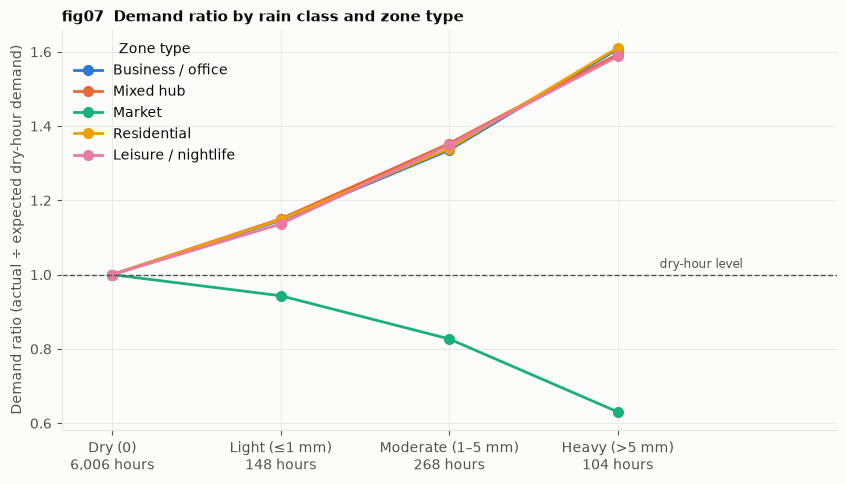

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(RAIN_LABELS))
for color, t in zip(SERIES, TYPE_ORDER):
    ax.plot(x, rain_effect.loc[t, RAIN_LABELS].values, color=color, marker="o", markersize=7, label=t.split(" (")[0])
ax.axhline(1, color=INK_2, linestyle="--", linewidth=1)
ax.text(len(x) - 1 + 0.25, 1.01, "dry-hour level", va="bottom", fontsize=8.5, color=INK_2)
ax.set_xticks(x, [f"{l}\n{counts[l]:,} hours" for l in RAIN_LABELS])
ax.set_xlim(-0.3, len(x) - 0.3 + 0.6)
ax.set_ylabel("Demand ratio (actual ÷ expected dry-hour demand)")
ax.legend(frameon=False, title="Zone type", loc="upper left")
ax.set_title("fig07  Demand ratio by rain class and zone type")
save(fig, "fig07_rain_effect.png")

## fig08 — Event study

Demand in the event's zone from 6 hours before to 12 hours after the start, divided by a non-event baseline: the mean for the same zone, weekday and hour over hours with no event within ±6 h and no public holiday.

In [12]:
STUDY_TYPES = ["football_match", "concert", "conference"]
WINDOW = range(-6, 13)
local = events[~events["event_type"].isin(["public_holiday", "school_break"])]
blocked = pd.concat([
    pd.DataFrame({"zone": r.zone, "pickup_hour": pd.date_range(r.start_datetime.floor("h") - pd.Timedelta(hours=6),
                                                               r.end_datetime.ceil("h") + pd.Timedelta(hours=6), freq="h")})
    for r in local.itertuples()]).drop_duplicates()
base_rows = trips[~trips["is_holiday"]].merge(blocked.assign(blocked=1), how="left", on=["zone", "pickup_hour"])
baseline = base_rows[base_rows["blocked"].isna()].groupby(["zone", "dow", "hour"])["trips"].mean().rename("baseline")

study = local[local["event_type"].isin(STUDY_TYPES)]
rows = []
for r in study.itertuples():
    for k in WINDOW:
        rows.append((r.event_id, r.event_type, r.zone, k, r.start_datetime.floor("h") + pd.Timedelta(hours=k)))
study_hours = pd.DataFrame(rows, columns=["event_id", "event_type", "zone", "rel_hour", "pickup_hour"])
study_hours = study_hours.merge(trips[["zone", "pickup_hour", "trips"]], on=["zone", "pickup_hour"], how="inner")
study_hours["dow"], study_hours["hour"] = study_hours["pickup_hour"].dt.dayofweek, study_hours["pickup_hour"].dt.hour
study_hours = study_hours.join(baseline, on=["zone", "dow", "hour"])
effect = (study_hours.groupby(["event_type", "rel_hour"])[["trips", "baseline"]].sum()
            .assign(ratio=lambda t: t["trips"] / t["baseline"])["ratio"].unstack(0))
n_events = study.groupby("event_type")["event_id"].nunique()
effect.round(2).T

rel_hour,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12
event_type,,,,,,,,,,,,,,,,,,,
concert,1.05,1.02,1.00,1.11,1.46,1.52,1.02,1.03,1.01,1.07,1.89,1.91,1.79,0.95,1.01,1.00,1.05,1.06,1.06
conference,0.93,1.03,1.11,1.10,0.93,1.29,1.34,0.96,0.95,0.92,0.92,0.93,0.92,0.96,1.52,1.47,0.95,0.92,0.95
football_match,1.01,0.95,0.93,1.14,1.72,1.62,1.31,1.30,2.20,2.00,1.09,1.00,1.02,1.04,0.98,1.01,0.98,0.86,0.94


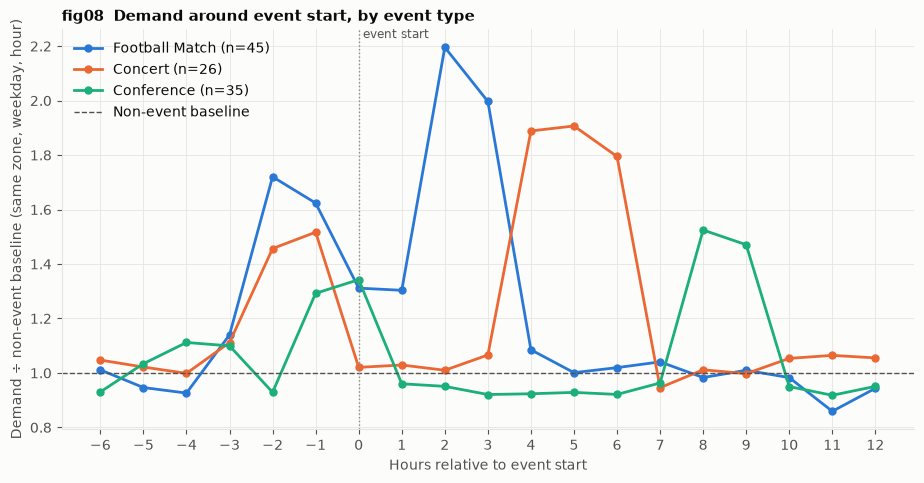

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.2))
for color, t in zip(SERIES, STUDY_TYPES):
    ax.plot(effect.index, effect[t], color=color, marker="o", markersize=5,
            label=f"{t.replace('_', ' ').title()} (n={n_events[t]})")
ax.axhline(1, color=INK_2, linestyle="--", linewidth=1, label="Non-event baseline")
ax.axvline(0, color=INK_3, linestyle=":", linewidth=1)
ax.text(0.1, ax.get_ylim()[1], "event start", va="top", fontsize=8.5, color=INK_2)
ax.set_xticks(list(WINDOW))
ax.set_xlabel("Hours relative to event start")
ax.set_ylabel("Demand ÷ non-event baseline (same zone, weekday, hour)")
ax.legend(frameon=False, loc="upper left")
ax.set_title("fig08  Demand around event start, by event type")
save(fig, "fig08_event_study.png")

## fig09 — Holiday effects

Index = mean trips per zone-hour on the holiday ÷ the mean on the same weekday in the 4 weeks before and after (excluding holidays and days with < 80% data), × 100. The 11 zones with data all year are used.

In [14]:
steady = trips[trips["zone"] != "Ayat"]
day = steady.groupby("date")["trips"].agg(["mean", "size"])
day = day[day["size"] >= 0.8 * 24 * steady["zone"].nunique()]["mean"]
normal_days = day[~day.index.isin(holiday_dates)]
hol = holiday_rows.drop_duplicates("event_id")[["event_name", "start_datetime"]].assign(date=lambda t: t["start_datetime"].dt.normalize())
rows = []
for h in hol.itertuples():
    same_dow = [h.date + pd.Timedelta(weeks=k) for k in [-4, -3, -2, -1, 1, 2, 3, 4]]
    ref = normal_days.reindex(same_dow).dropna()
    rows.append((h.event_name.split(" (")[0], h.date, day.get(h.date, np.nan), ref.mean(), len(ref)))
holiday_index = pd.DataFrame(rows, columns=["holiday", "date", "holiday_mean", "normal_mean", "ref_days"])
holiday_index["index"] = 100 * holiday_index["holiday_mean"] / holiday_index["normal_mean"]
holiday_index = holiday_index.sort_values("index")
holiday_index.round(1)

,holiday,date,holiday_mean,normal_mean,ref_days,index
4,Good Friday,2025-04-18,22.0,30.2,8,72.9
0,Genna,2025-01-07,18.8,25.0,4,75.4
7,Patriots' Victory Day,2025-05-05,22.4,29.7,7,75.5
9,Eid al-Adha,2025-06-06,24.7,31.9,8,77.6
10,Mawlid,2025-09-04,27.3,33.7,7,81.0
3,Eid al-Fitr,2025-03-31,23.3,28.2,8,82.5
8,Downfall of the Derg,2025-05-28,24.7,29.9,8,82.7
11,Enkutatash,2025-09-11,28.4,33.9,7,83.6
6,International Labour Day,2025-05-01,24.5,28.8,8,85.0
12,Meskel,2025-09-27,30.7,31.7,8,96.7


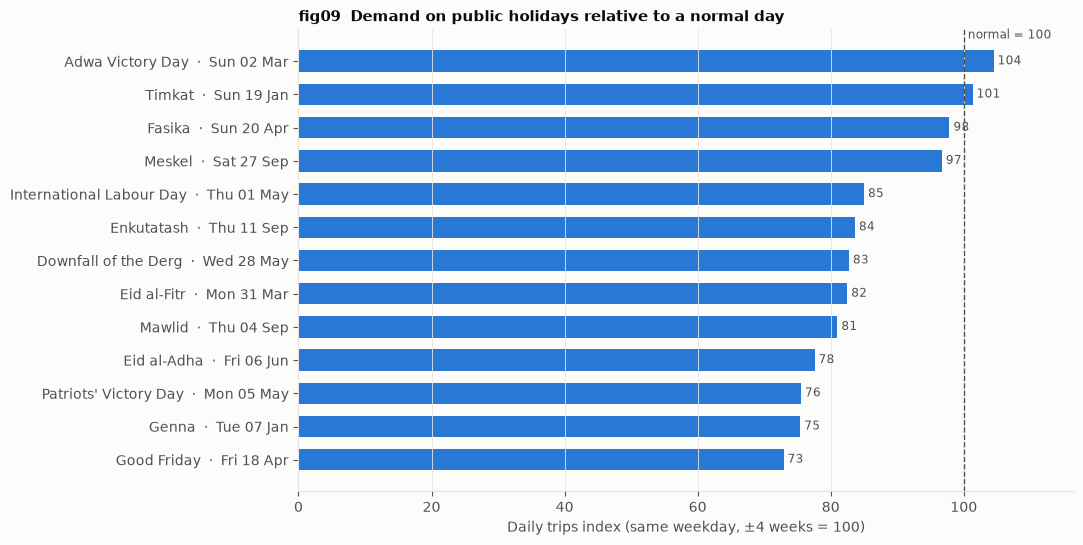

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r.holiday}  ·  {r.date:%a %d %b}" for r in holiday_index.itertuples()]
ax.barh(labels, holiday_index["index"], color=BLUE, height=0.65)
for y, v in enumerate(holiday_index["index"]):
    ax.text(v, y, f" {v:.0f}", va="center", fontsize=8.5, color=INK_2)
ax.axvline(100, color=INK_2, linestyle="--", linewidth=1)
ax.text(100, len(labels) - 0.4, " normal = 100", fontsize=8.5, color=INK_2, va="bottom")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(110, holiday_index["index"].max() + 12))
ax.set_xlabel("Daily trips index (same weekday, ±4 weeks = 100)")
ax.set_title("fig09  Demand on public holidays relative to a normal day")
save(fig, "fig09_holiday_effects.png")